# Linear Regression Predicting Horsepower

In [2]:
import pandas as pd # for data manipulation
import matplotlib.pyplot as plt # for plotting
import seaborn as sns # for data visualization
import numpy as np # for numerical operations
import re # for regular expressions
from sklearn.model_selection import train_test_split # for splitting the dataset
from sklearn.linear_model import LinearRegression # for linear regression model
from sklearn.metrics import mean_squared_error, r2_score # for model evaluation

# Load the dataset
df = pd.read_excel('CarsDataset.xlsx')

# Clean the Dataset

In [3]:
# Drop rows with NaN in X or y

# Extract the first number from a string, handling commas and spaces
def extract_first_number(x):
    nums = re.findall(r'\d+', str(x)) # extract all numbers
    for n in nums:
        n_clean = n.replace(',', ''). replace(' ', '') # clean the number
        if n_clean and n_clean != '.': 
            try: 
                return float(n_clean) # convert to float
            except:
                continue
    return np.nan

# Extract the average of two numbers
def extract_average_range_safe(x):
    nums = [n for n in re.findall(r"[\d,.]+", str(x)) if n.replace(',', '').replace('.', '').strip() != ""] # extract numbers, ignoring empty strings
    try:
        if len(nums) == 2: 
            v1 = float(nums[0].replace(',', '').replace(' ', '')) 
            v2 = float(nums[1].replace(',', '').replace(' ', '')) 
            return (v1 + v2) / 2 
        elif len(nums) == 1: 
            return float(nums[0].replace(',', '').replace(' ', '')) 
        else:
            return np.nan 
    except:
        return np.nan 

In [4]:
# Extract only numeric values from the relevant columns
df_clean = df.copy()
df_clean['Engine_CC']      = df_clean['CC/Battery Capacity'].apply(extract_first_number)
df_clean['HorsePower']     = df_clean['HorsePower'].apply(extract_average_range_safe)
df_clean['Max_Speed_kmh']  = df_clean['Total Speed'].apply(extract_first_number)
df_clean['Torque_Nm']      = df_clean['Torque'].apply(extract_average_range_safe) 
df_clean['Zero_100_Sec']   = df_clean['Performance(0 - 100 )KM/H'].apply(extract_first_number)

# Select the features and target variable
X = df_clean[['Engine_CC', 'Max_Speed_kmh', 'Torque_Nm', 'Zero_100_Sec']] # Features
y = df_clean['HorsePower'] # Target variable

# Drop rows with NaN in X or y
Xy = pd.concat([X, y], axis=1).dropna()
X_clean = Xy[['Engine_CC', 'Max_Speed_kmh', 'Torque_Nm', 'Zero_100_Sec']]
y_clean = Xy['HorsePower']

# Model

In [7]:

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size = 0.2, random_state = 30)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficient Interpretation
print("Intercept:", model.intercept_) # The regression intercept
coefficients = pd.DataFrame({
    'Feature': X_train.columns, 
    'Coefficient': model.coef_ # The coefficients for each feature (their impact on the target variable)
})
print(coefficients)

# Training predictions
y_train_pred = model.predict(X_train)

# Evaluate on training data
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print(f"Training R^2: {r2_train:.4f}")
print(f"Training MSE: {mse_train:.4f}")

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred) # R-squared value to evaluate the model's performance
mse = mean_squared_error(y_test, y_pred) # Mean Squared Error to evaluate the model's performance
print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

Intercept: -205.21550759301215
         Feature  Coefficient
0      Engine_CC     0.021126
1  Max_Speed_kmh     2.348548
2      Torque_Nm     0.070787
3   Zero_100_Sec    -8.872208
Training R^2: 0.7241
Training MSE: 12638.9659
R^2: 0.7238
MSE: 12498.9236


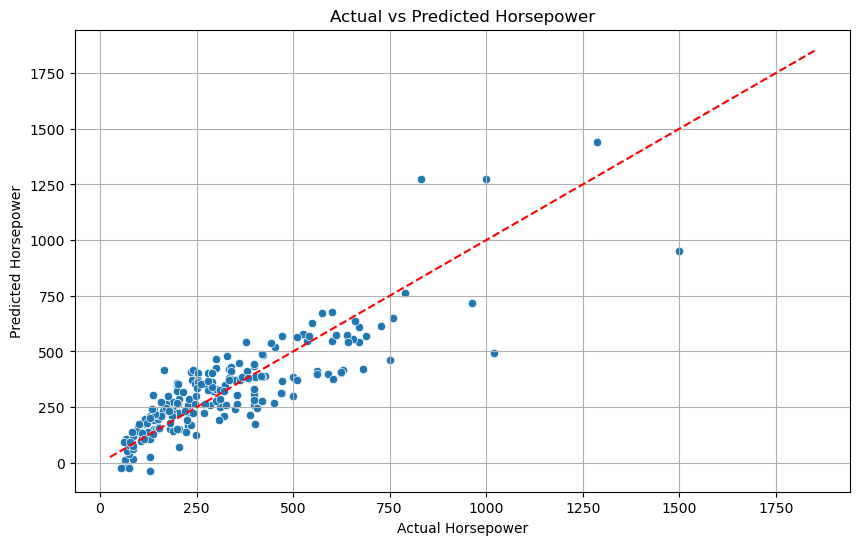

In [6]:
# Plot Predicted vs Actual Horsepower
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Horsepower')
plt.ylabel('Predicted Horsepower')
plt.title('Actual vs Predicted Horsepower')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # diagonal reference line
plt.grid(True)
plt.show()